In [1]:
from functools import partial
import contextlib
from pathlib import Path

import jax
import jax.numpy as jnp
import jax.experimental.pallas as pl
import jax.experimental.pallas.tpu as pltpu

In [2]:
@contextlib.contextmanager
def profile(path="/tmp/profiles", port=8791):
  with jax.profiler.trace("/tmp/profiles"):
    yield
  profiles = sorted(Path(path).absolute().glob("**/*.xplane.pb"), key=lambda x: x.stat().st_mtime)
  profile_name = profiles[-1].parts[-2]
  if port == 8791:
    url = "http://localhost:{port}/data/plugin/profile/trace_viewer@;run={name};tag=trace_viewer@"  # xprof version
  else:
    url = "http://localhost:{port}/?run={name}&tag=trace_viewer"  # tensorboard version
  print(url.format(port=port, name=profile_name))

# Pallas on TPUs

In [7]:
def kernel(x_ref, y_ref, z_ref):
  z_ref[...] = x_ref[...] + y_ref[...]
  
x = jnp.ones((16, 16))
y = jnp.ones((16, 16))

out_shape = jax.ShapeDtypeStruct(x.shape, x.dtype)

z = pl.pallas_call(kernel, out_shape=out_shape)(x, y)

In [9]:
x, y = jnp.ones((8192, 8192)), jnp.ones((8192, 8192))

z = jax.jit(pl.pallas_call(kernel, out_shape=x))(x, y)

JaxRuntimeError: RESOURCE_EXHAUSTED: Allocation (size=268435456) would exceed memory (size=134217728) :: #allocation2 [shape = 'u8[268435456]{0}', space=vmem, size = 0x10000000, tag = 'input window allocation for operator input 0. The window shape is f32[8192,8192], while the full shape is f32[8192,8192]. The u8 shape/size shown above represents the raw byte size of this window in VMEM. This allocation is single buffered.'] :: tpu_custom_call.1

In [10]:
x.shape

(8192, 8192)

In [16]:
block_shape = 1024
spec = pl.BlockSpec((block_shape, block_shape), lambda i, j: (i, j))
in_specs = [spec, spec]
out_spec = spec

n = x.shape[0] // block_shape

z = pl.pallas_call(kernel, out_shape=x, in_specs=in_specs, out_specs=out_spec, grid=(n, n))(x, y)

In [17]:
z

Array([[2., 2., 2., ..., 2., 2., 2.],
       [2., 2., 2., ..., 2., 2., 2.],
       [2., 2., 2., ..., 2., 2., 2.],
       ...,
       [2., 2., 2., ..., 2., 2., 2.],
       [2., 2., 2., ..., 2., 2., 2.],
       [2., 2., 2., ..., 2., 2., 2.]], dtype=float32)

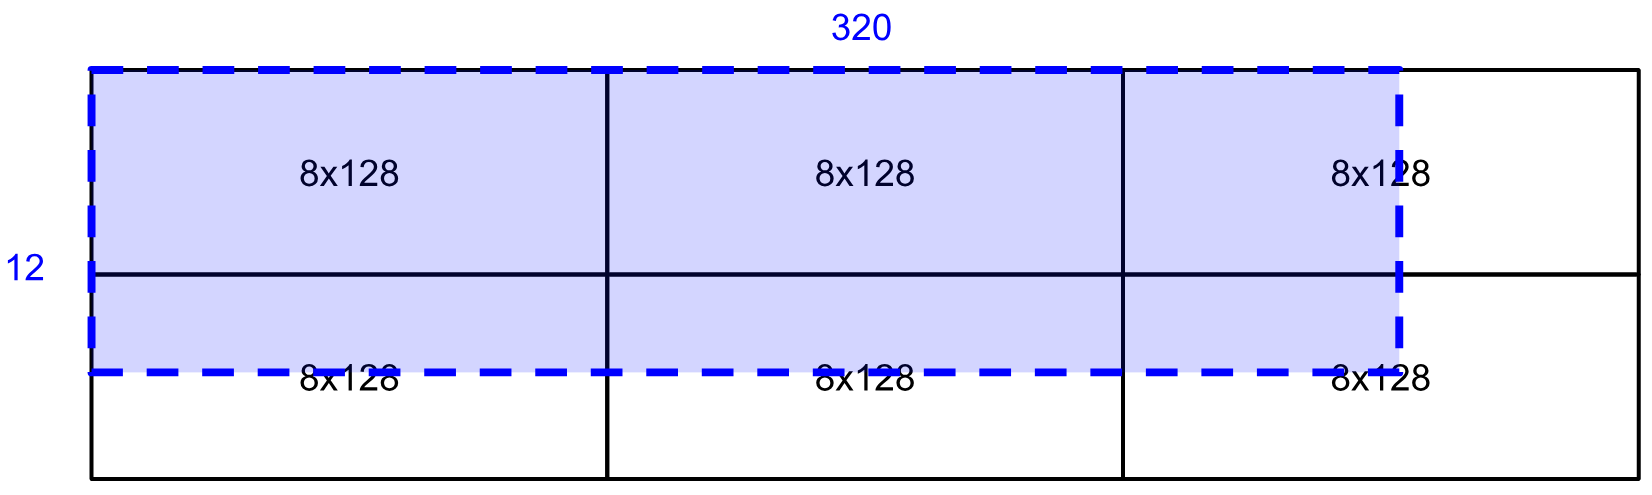

### When to mask

In [19]:
def kernel(x_ref, y_ref, out_ref):
  out_ref[...] = jnp.dot(x_ref[...], y_ref[...], preferred_element_type=jnp.float32).astype(out_ref.dtype)

x = jnp.ones((128, 4096))
y = jnp.ones((4096, 128))

z = pl.pallas_call(kernel, out_shape=jax.ShapeDtypeStruct((x.shape[0], y.shape[1]), x.dtype))(x, y)
z

Array([[4096., 4096., 4096., ..., 4096., 4096., 4096.],
       [4096., 4096., 4096., ..., 4096., 4096., 4096.],
       [4096., 4096., 4096., ..., 4096., 4096., 4096.],
       ...,
       [4096., 4096., 4096., ..., 4096., 4096., 4096.],
       [4096., 4096., 4096., ..., 4096., 4096., 4096.],
       [4096., 4096., 4096., ..., 4096., 4096., 4096.]], dtype=float32)

In [21]:
x = jnp.ones((128, 3541))
y = jnp.ones((3541, 128))

z = pl.pallas_call(kernel, out_shape=jax.ShapeDtypeStruct((x.shape[0], y.shape[1]), x.dtype))(x, y)
z

Array([[3541., 3541., 3541., ..., 3541., 3541., 3541.],
       [3541., 3541., 3541., ..., 3541., 3541., 3541.],
       [3541., 3541., 3541., ..., 3541., 3541., 3541.],
       ...,
       [3541., 3541., 3541., ..., 3541., 3541., 3541.],
       [3541., 3541., 3541., ..., 3541., 3541., 3541.],
       [3541., 3541., 3541., ..., 3541., 3541., 3541.]], dtype=float32)

In [24]:
def kernel(x_ref, y_ref, out_ref):
  @pl.when(pl.program_id(0) == 0)
  def _():
    out_ref[...] = jnp.zeros_like(out_ref)

  out_ref[...] += jnp.dot(x_ref[...], y_ref[...], preferred_element_type=jnp.float32).astype(out_ref.dtype)


x = jnp.ones((128, 3541), "bfloat16")
y = jnp.ones((3541, 128), "bfloat16")

in_specs = [
  pl.BlockSpec((x.shape[0], block_shape), lambda i: (0, i)),
  pl.BlockSpec((block_shape, y.shape[1]), lambda i: (i, 0)),
]
out_shape = jax.ShapeDtypeStruct((x.shape[0], y.shape[1]), x.dtype)
grid = (pl.cdiv(x.shape[-1], block_shape),)

z = pl.pallas_call(kernel, out_shape=out_shape, grid=grid, in_specs=in_specs)(x, y)
z

Array([[4080, 4080, 4080, ..., 4080, 4080, 4080],
       [4080, 4080, 4080, ..., 4080, 4080, 4080],
       [4080, 4080, 4080, ..., 4080, 4080, 4080],
       ...,
       [4080, 4080, 4080, ..., 4080, 4080, 4080],
       [4080, 4080, 4080, ..., 4080, 4080, 4080],
       [4080, 4080, 4080, ..., 4080, 4080, 4080]], dtype=bfloat16)

In [27]:
def kernel(x_ref, y_ref, out_ref, *, k: int, block_shape: int):
  @pl.when(pl.program_id(0) == 0)
  def _():
    out_ref[...] = jnp.zeros_like(out_ref)
  
  def matmul():
    out_ref[...] += jnp.dot(x_ref[...], y_ref[...], preferred_element_type=jnp.float32).astype(out_ref.dtype)

  def masked_matmul():
    x_mask = jax.lax.broadcasted_iota(jnp.int32, x_ref.shape, 1) < (k % block_shape)
    x = jnp.where(x_mask, x_ref[...], 0)
    y_mask = jax.lax.broadcasted_iota(jnp.int32, y_ref.shape, 0) < (k % block_shape)
    y = jnp.where(y_mask, y_ref[...], 0)

    out_ref[...] += jnp.dot(x, y, preferred_element_type=jnp.float32).astype(out_ref.dtype)
    
  if k % block_shape == 0:
      matmul()
  else:
    jax.lax.cond(
      pl.program_id(0) == pl.num_programs(0) - 1,
      masked_matmul,
      matmul,
    )

block_shape = 128

x = jnp.ones((128, 3541), "bfloat16")
y = jnp.ones((3541, 128), "bfloat16")

in_specs = [
  pl.BlockSpec((x.shape[0], block_shape), lambda i: (0, i)),
  pl.BlockSpec((block_shape, y.shape[1]), lambda i: (i, 0)),
]
out_shape = jax.ShapeDtypeStruct((x.shape[0], y.shape[1]), x.dtype)
grid = (pl.cdiv(x.shape[-1], block_shape),)

z = pl.pallas_call(
  partial(kernel, k=x.shape[1], block_shape=block_shape),
  out_shape=out_shape, grid=grid, in_specs=in_specs
)(x, y)
z

Array([[3536, 3536, 3536, ..., 3536, 3536, 3536],
       [3536, 3536, 3536, ..., 3536, 3536, 3536],
       [3536, 3536, 3536, ..., 3536, 3536, 3536],
       ...,
       [3536, 3536, 3536, ..., 3536, 3536, 3536],
       [3536, 3536, 3536, ..., 3536, 3536, 3536],
       [3536, 3536, 3536, ..., 3536, 3536, 3536]], dtype=bfloat16)

### Pallas acts as a layout constraint

In [4]:
def kernel(x_ref, out_ref):
  out_ref[...] = x_ref[...]
  
x = jnp.arange(8192) * jnp.ones((8192, 1), "bfloat16")

@jax.jit
def fn(x):
  x = x.T
  block_shape = 128
  spec = pl.BlockSpec((block_shape, x.shape[1]), lambda i: (i, 0))
  y = pl.pallas_call(kernel, grid=(x.shape[0] // block_shape), out_shape=x, in_specs=[spec], out_specs=spec)(x)
  return y.T

jax.block_until_ready(fn(x))
with profile():
  jax.block_until_ready(fn(x))

http://localhost:8791/data/plugin/profile/trace_viewer@;run=2025_11_21_00_21_24;tag=trace_viewer@


In [7]:
from pprint import pprint
pprint(x.format)

Format(layout=Layout(major_to_minor=(0, 1), tiling=((8, 128), (2, 1)), sub_byte_element_size_in_bits=0), sharding=SingleDeviceSharding(device=TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), memory_kind=device))


In [8]:
from jax.experimental.layout import Layout, Format

### Control flow

In [ ]:
@jax.jit
def alternate_rows(x, mask):
  x = x.reshape((x.shape[0], 1, x.shape[1]))
  block_shape = 128

  in_specs = [
    pl.BlockSpec((128, 1, x.shape[-1]), lambda i: (i, 0, 0), memory_space=pltpu.VMEM),
    pl.BlockSpec(mask.shape, memory_space=pltpu.SMEM)
  ]

  grid = (x.shape[0] // block_shape,)

  def kernel(x_ref, mask_ref, out_ref):
    mask_idx0 = pl.program_id(0) * block_shape
    for i in range(x_ref.shape[0]):
      @pl.when(mask_ref[mask_idx0 + i])
      def _():
        out_ref[i, ...] = x_ref[i, ...]

      @pl.when(~mask_ref[mask_idx0 + i])
      def _():
        out_ref[i, ...] = -x_ref[i, ...]

  out = pl.pallas_call(kernel, out_shape=x, in_specs=in_specs, out_specs=in_specs[0], grid=grid)(x, mask)
  return out.reshape((x.shape[0], x.shape[-1]))

In [ ]:
x = jnp.arange(8192)[:, None] * jnp.ones((1, 8192), "float32")
mask = jnp.arange(x.shape[0]) % 2 == 0
jax.block_until_ready(alternate_rows(x, mask))
with profile():
  jax.block_until_ready(alternate_rows(x, mask))

http://localhost:8791/data/plugin/profile/trace_viewer@;run=2025_11_20_01_23_46;tag=trace_viewer@


In [ ]:
y = alternate_rows(x, mask)

### A full matmul

In [29]:
def matmul_kernel(x_ref, y_ref, out_ref, acc_ref):
  with jax.named_scope("clear"):
    @pl.when(pl.program_id(2) == 0)
    def _ ():
      acc_ref[...] = jnp.zeros_like(acc_ref)

  with jax.named_scope("dot"):
    acc_ref[...] += jnp.dot(x_ref[...], y_ref[...], preferred_element_type=acc_ref.dtype)

  with jax.named_scope("store"):
    @pl.when(pl.program_id(2) == pl.num_programs(2) - 1)
    def _ ():
      out_ref[...] = acc_ref[...].astype(out_ref.dtype)

def matmul(x, y, block_shapes):
  block_m, block_k, block_n = block_shapes
  (m, _), (k, n) = x.shape, y.shape

  grid = (pl.cdiv(m, block_m), pl.cdiv(n, block_n), pl.cdiv(k, block_k))
  out_shape = jax.ShapeDtypeStruct((m, n), "bfloat16")
  in_specs = [
    pl.BlockSpec((block_m, block_k), lambda i, j, k: (i, k)),
    pl.BlockSpec((block_k, block_n), lambda i, j, k: (k, j))
  ]
  out_specs = pl.BlockSpec((block_m, block_n), lambda i, j, k: (i, j))
  scratch_shapes = [pltpu.VMEM((block_m, block_n), jnp.float32)]
  return pl.pallas_call(
    matmul_kernel,
    out_shape=out_shape, grid=grid, in_specs=in_specs, out_specs=out_specs, scratch_shapes=scratch_shapes,
  )(x, y)

In [31]:
x = jnp.ones((8192, 8192), "bfloat16")
y = jnp.ones((8192, 8192), "bfloat16")
block_shapes = (1024, 1024, 1024)

z = jax.block_until_ready(matmul(x, y, block_shapes))
with profile():
  z1 = jax.block_until_ready(matmul(x, y, block_shapes))
  z2 = jax.block_until_ready(jnp.dot(x, y))

http://localhost:8791/data/plugin/profile/trace_viewer@;run=2025_11_20_18_21_29;tag=trace_viewer@


### Profiling

In [32]:
fn = jax.jit(partial(matmul, block_shapes=block_shapes)).lower(x, y).compile({"xla_enable_transpose_trace": True})
fn(x, y)
with profile():
  jax.block_until_ready(fn(x, y))

http://localhost:8791/data/plugin/profile/trace_viewer@;run=2025_11_20_18_23_18;tag=trace_viewer@


In [33]:
import tune_jax

blocks = [512, 1024, 2048]
hparams = dict(
  block_m=blocks,
  block_k=blocks,
  block_n=blocks
)

tune_jax.logger.setLevel("INFO")
fn = tune_jax.tune(lambda x, y, block_m, block_k, block_n: matmul(x, y, (block_m, block_k, block_n)), hyperparams=hparams)
fn(x, y)
print(tune_jax.tabulate(fn))

Profiling tpu:   0%|          | 0/5 [00:00<?, ?it/s]

Saving optimization profile to `/tmp/tuning_profile_2025-11-20_18:25:19_pr1b2lqw`


Profiling tpu: 100%|██████████| 5/5 [00:15<00:00,  3.08s/it]


  id    block_m    block_k    block_n    t_mean (s)    t_std (s)
----  ---------  ---------  ---------  ------------  -----------
  14       1024       1024       2048    1.4430e-03   8.2716e-05
  11       1024        512       2048    1.4841e-03   5.7944e-07
  19       2048        512       1024    1.4991e-03   5.6771e-06
  13       1024       1024       1024    1.7389e-03   1.7383e-05
   8        512       2048       2048    1.8958e-03   6.4060e-05
   5        512       1024       2048    1.9442e-03   7.2777e-05
  21       2048       1024        512    1.9490e-03   7.5599e-05
  16       1024       2048       1024    2.0348e-03   2.9375e-04
  10       1024        512       1024    2.0608e-03   1.0841e-04
  18       2048        512        512    2.1409e-03   1.8224e-06
  15       1024       2048        512    2.2516e-03   1.3558e-04
   7        512       2048       1024    2.3134e-03   5.4118e-05
   2        512        512       2048    2.4642e-03   3.1054e-04
   4        512       102

In [34]:
with profile():
  z1 = jax.block_until_ready(fn(x, y))
  z2 = jax.block_until_ready(jnp.dot(x, y))

http://localhost:8791/data/plugin/profile/trace_viewer@;run=2025_11_20_18_25_45;tag=trace_viewer@


# Custom Memory Pipelines

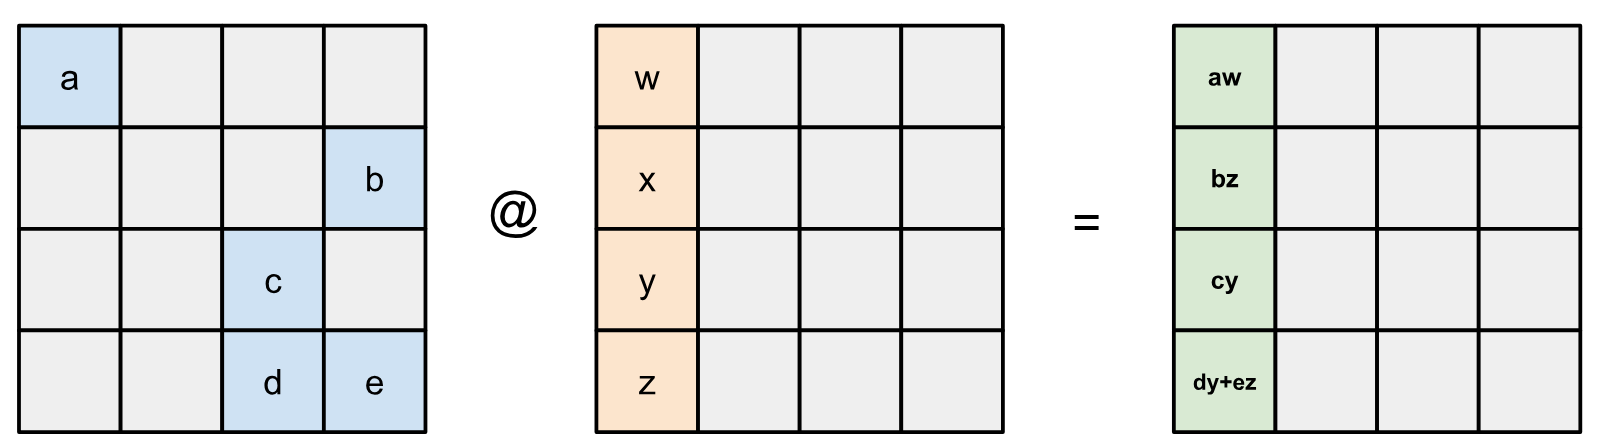

In [35]:
blocks_map = jnp.array([1, 5, 2])

def scatter_blocks(x, y, idx, *, block_shape: int):
  def kernel(idx_ref, x_ref, y_ref, out_ref):
    del idx_ref, y_ref
    out_ref[...] = x_ref[...]
    
  out_specs = pl.BlockSpec((block_shape, x.shape[1]), lambda i, idx_ref: (idx_ref[i], 0))
  in_specs = [
    pl.BlockSpec((block_shape, x.shape[1]), lambda i, idx_ref: (i, 0)),
    out_specs,  # alias of y
  ]

  grid_spec = pltpu.PrefetchScalarGridSpec(
    num_scalar_prefetch=1,
    grid=(blocks_map.size,),
    in_specs=in_specs,
    out_specs=out_specs,
  )
  return pl.pallas_call(kernel, out_shape=y, grid_spec=grid_spec, input_output_aliases={2: 0})(idx, x, y)

In [36]:
x = jnp.arange(128)[:, None] * jnp.ones((1, 1))
y = jnp.zeros_like(x)
y = scatter_blocks(x, y, blocks_map, block_shape=8)

In [37]:
y.reshape(-1)

Array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  3.,  4.,
        5.,  6.,  7., 16., 17., 18., 19., 20., 21., 22., 23.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  8.,  9., 10., 11., 12., 13., 14., 15.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],      dtype=float32)

### Grid can be dynamic (e.g., avoid recompilation, variable work)

In [44]:
blocks_map = jnp.array([1, 5, 2])

@partial(jax.jit, static_argnames=("block_shape",))
def scatter_blocks(x, y, idx, total, *, block_shape: int):
  def kernel(idx_ref, x_ref, y_ref, out_ref):
    del idx_ref, y_ref
    out_ref[...] = x_ref[...]
    
  out_specs = pl.BlockSpec((block_shape, x.shape[1]), lambda i, idx_ref: (idx_ref[i], 0))
  in_specs = [
    pl.BlockSpec((block_shape, x.shape[1]), lambda i, idx_ref: (i, 0)),
    out_specs,  # alias of y
  ]
    
  grid_spec = pltpu.PrefetchScalarGridSpec(
    num_scalar_prefetch=1,
    grid=(total,),
    in_specs=in_specs,
    out_specs=out_specs,
  )
  return pl.pallas_call(kernel, out_shape=y, grid_spec=grid_spec, input_output_aliases={2: 0})(idx, x, y)

In [45]:
x = jnp.arange(128)[:, None] * jnp.ones((1, 1))
y = jnp.zeros_like(x)
y = scatter_blocks(x, y, blocks_map, total=2, block_shape=8)

In [43]:
y.reshape(-1)

Array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  3.,  4.,
        5.,  6.,  7.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  8.,  9., 10., 11., 12., 13., 14., 15.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],      dtype=float32)

# Manual HBM <-> VMEM Management

### Fastest possible buffer allocation.

In [46]:
@partial(jax.jit, static_argnames=("shape", "dtype"))
def empty(shape, dtype=jnp.bfloat16):
  kernel = lambda out_ref: None
  out_specs = pl.BlockSpec(shape, memory_space=pltpu.HBM)
  return pl.pallas_call(kernel, out_shape=jax.ShapeDtypeStruct(shape, dtype), out_specs=out_specs)()

In [48]:
def allocations(shape, dtype):
  with jax.named_scope("ones"):
    x1 = jnp.ones(shape, dtype)
  with jax.named_scope("zeros"):
    x2 = jnp.zeros(shape, dtype)
  with jax.named_scope("empty"):
    x3 = jnp.empty(shape, dtype)
  with jax.named_scope("pallas_empty"):
    x4 = empty(shape, dtype)
  return x1, x2, x3, x4

shape, dtype = (8192, 8192), jnp.bfloat16
jax.block_until_ready(allocations(shape, dtype))  # to compile
with profile():
  jax.block_until_ready(allocations(shape, dtype))

http://localhost:8791/data/plugin/profile/trace_viewer@;run=2025_11_20_18_33_32;tag=trace_viewer@


### Simple DMAs

In [310]:
def copy(x):

  def kernel(x_hbm_ref, y_hbm_ref):
    pltpu.sync_copy(x_hbm_ref, y_hbm_ref)

  in_specs = [pl.BlockSpec(memory_space=pltpu.HBM)]
  out_specs = pl.BlockSpec(memory_space=pltpu.HBM)

  return pl.pallas_call(kernel, out_shape=x, in_specs=in_specs, out_specs=out_specs)(x)

In [311]:
copy(x)

Array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

In [312]:
x = jnp.ones((128, 128))
jax.block_until_ready(copy(x))
with profile():
  jax.block_until_ready(copy(x))

http://localhost:8791/data/plugin/profile/trace_viewer@;run=2025_11_20_02_58_06;tag=trace_viewer@


### pl.run_scoped - allocate temporary state

In [315]:
def copy(x):

  def kernel(x_hbm_ref, y_hbm_ref):
    @partial(pl.run_scoped, sem=pltpu.SemaphoreType.DMA)
    def _(sem):
      copy_op = pltpu.make_async_copy(x_hbm_ref, y_hbm_ref, sem=sem)
      with jax.named_scope("start"):
        copy_op.start()
      with jax.named_scope("wait"):
        copy_op.wait()

  in_specs = [pl.BlockSpec(memory_space=pltpu.HBM)]
  out_specs = pl.BlockSpec(memory_space=pltpu.HBM)

  return pl.pallas_call(kernel, out_shape=x, in_specs=in_specs, out_specs=out_specs)(x)

In [319]:
fn = jax.jit(copy).lower(x).compile({"xla_enable_transpose_trace": True})
jax.block_until_ready(fn(x))
with profile():
  jax.block_until_ready(fn(x))

http://localhost:8791/data/plugin/profile/trace_viewer@;run=2025_11_20_03_05_28;tag=trace_viewer@


### pl.core_map

In [338]:
@jax.jit
def copy(x):
  x_hbm_ref = jax.new_ref(x)
  y_hbm_ref = jax.new_ref(jnp.empty_like(x))

  @pl.core_map(mesh=pltpu.create_tensorcore_mesh("core"))
  def _():
    pltpu.sync_copy(x_hbm_ref, y_hbm_ref)

  return y_hbm_ref[...]

In [358]:
@partial(jax.jit, static_argnames=("block_shape",))
def block_gather(x, block_idx, *, block_shape: int):
  x_hbm_ref = jax.new_ref(x)
  y_hbm_ref = jax.new_ref(jnp.empty_like(x))
  block_idx_ref = jax.new_ref(block_idx)

  @pl.core_map(mesh=pltpu.create_tensorcore_mesh("core"))
  def _():
    @partial(pl.run_scoped, idx_smem_ref=pltpu.SMEM(block_idx.shape, jnp.int32))
    def _(idx_smem_ref):
      pltpu.sync_copy(block_idx_ref, idx_smem_ref)

      def set_kernel(x_ref, y_ref):
        y_ref[...] = x_ref[...]
        
      in_specs = [pl.BlockSpec((block_shape, x.shape[1]), lambda i: (idx_smem_ref[i], 0))]
      out_specs = pl.BlockSpec((block_shape, x.shape[1]), lambda i: (i, 0))
        
      pltpu.emit_pipeline(
        set_kernel,
        in_specs=in_specs,
        out_specs=out_specs,
        grid=(pl.cdiv(x.shape[0], block_shape),),
      )(x_hbm_ref, y_hbm_ref)

  return y_hbm_ref[...]

In [359]:
block_shape = 8
x = jnp.arange(1024)[:, None] * jnp.ones((1, 128))
block_idx = jnp.argsort(jax.random.normal(jax.random.key(0), pl.cdiv(x.shape[0], block_shape)))
y1 = block_gather(x, block_idx, block_shape=block_shape)
y2 = x.reshape((-1, block_shape, x.shape[1]))[block_idx, ...].reshape(x.shape)

# Distributed Computing

### Pallas ra2a kernel

In [49]:
import dataclasses
from typing import Any, Callable

from jax import lax

AsyncCopyDescriptor = Any

@dataclasses.dataclass
class RDMACopy:
  copy: AsyncCopyDescriptor | None
  start: Callable[[], None]
  wait: Callable[[], None]

In [50]:
def _ra2a_3d_kernel_sync(
  src_ref, out_ref, input_offsets, send_sizes, output_offsets, recv_sizes, dst_ref, sems, *, axis_name
):
  del out_ref  # aliased in dst_ref
  idx, n_devices = jax.lax.axis_index(axis_name), jax.lax.axis_size(axis_name)

  def make_dma(id):
    sem_id = lax.rem(idx + idx, n_devices)
    # src = src_ref.at[pl.ds(input_offsets[id], send_sizes[id]), ...]
    # dst = dst_ref.at[pl.ds(output_offsets[id], send_sizes[id]), ...]
    src = src_ref.at[pl.ds(input_offsets[id], send_sizes[id]), ...]
    dst = dst_ref.at[pl.ds(output_offsets[id], send_sizes[id]), ...]
    copy = pltpu.make_async_copy(src, dst, sems.at[0, sem_id, 1])
    return RDMACopy(copy, copy.start, copy.wait)

  dma_copy = make_dma(idx)
  dma_copy.start()

  def make_rdma(other_id, send: bool = True):
    src_id, dst_id = (idx, other_id) if send else (other_id, idx)
    size = lax.select(idx == src_id, send_sizes[dst_id], recv_sizes[src_id])
    src = src_ref.at[pl.ds(input_offsets[dst_id], size), ...]
    dst = dst_ref.at[pl.ds(output_offsets[dst_id], size), ...]
    sem_id, direction_id = lax.rem(idx + other_id, n_devices), (src_id > dst_id).astype(jnp.int32)
    send_sem = sems.at[sem_id, direction_id, 0]
    recv_sem = sems.at[sem_id, direction_id, 1]
    copy = pltpu.make_async_remote_copy(src, dst, send_sem, recv_sem, device_id=dst_id)
    start_fn = copy.start if send else (lambda: None)
    wait_fn = copy.wait_send if send else copy.wait_recv
    return RDMACopy(copy, start_fn, wait_fn)

  send_rdmas, recv_rdmas = [], []
  for i in range(1, n_devices):
    other_id = jax.lax.rem(idx + i, n_devices)
    send_rdmas.append(make_rdma(other_id, send=True))
    recv_rdmas.append(make_rdma(other_id, send=False))
  [rdma.start() for rdma in send_rdmas]
  [rdma.wait() for rdma in (send_rdmas + recv_rdmas)]
  dma_copy.wait()

In [51]:
@partial(jax.jit, static_argnames=("axis_name",))
def ra2a_3d(src, output, input_offsets, send_sizes, output_offsets, recv_sizes, *, axis_name: str = "x"):
  n_devices = jax.lax.axis_size(axis_name)
  out = pl.pallas_call(
    partial(_ra2a_3d_kernel_sync, axis_name=axis_name),
    out_shape=output,
    in_specs=2 * [pl.BlockSpec(memory_space=pltpu.ANY)] + 4 * [pl.BlockSpec(memory_space=pltpu.SMEM)],
    out_specs=pl.BlockSpec(memory_space=pltpu.ANY),
    scratch_shapes=[pltpu.SemaphoreType.DMA((n_devices, 2, 2))],
    input_output_aliases={1: 0},
    interpret=False,
  )(src, output, input_offsets, send_sizes, output_offsets, recv_sizes)
  return out


### Pallas ra2a async kernel

In [52]:
def _ra2a_3d_kernel_async(
  src_ref,
  out_ref,
  input_offsets,
  send_sizes,
  output_offsets,
  recv_sizes,
  dst_ref,
  sems,
  *,
  axis_name,
  start: bool = True,
):
  del out_ref  # aliased in dst_ref
  idx, n_devices = jax.lax.axis_index(axis_name), jax.lax.axis_size(axis_name)

  def make_dma(id):
    sem_id = jax.lax.rem(idx + idx, n_devices)
    src = src_ref.at[pl.ds(input_offsets[id], send_sizes[id]), ...]
    dst = dst_ref.at[pl.ds(output_offsets[id], send_sizes[id]), ...]
    copy = pltpu.make_async_copy(src, dst, sems.at[0, sem_id, 1])
    return RDMACopy(copy, copy.start, copy.wait)

  dma_copy = make_dma(idx)
  if start:
    dma_copy.start()

  def make_rdma(other_id, send: bool = True):
    src_id, dst_id = (idx, other_id) if send else (other_id, idx)
    size = lax.select(idx == src_id, send_sizes[dst_id], recv_sizes[src_id])
    src = src_ref.at[pl.ds(input_offsets[dst_id], size), ...]
    dst = dst_ref.at[pl.ds(output_offsets[dst_id], size), ...]
    sem_id, direction_id = lax.rem(idx + other_id, n_devices), (src_id > dst_id).astype(jnp.int32)
    send_sem = sems.at[sem_id, direction_id, 0]
    recv_sem = sems.at[sem_id, direction_id, 1]
    copy = pltpu.make_async_remote_copy(src, dst, send_sem, recv_sem, device_id=dst_id)
    start_fn = copy.start if send else (lambda: None)
    wait_fn = copy.wait_send if send else copy.wait_recv
    return RDMACopy(copy, start_fn, wait_fn)

  send_rdmas, recv_rdmas = [], []
  for i in range(1, n_devices):
    other_id = jax.lax.rem(idx + i, n_devices)
    send_rdmas.append(make_rdma(other_id, send=True))
    recv_rdmas.append(make_rdma(other_id, send=False))

  if start:
    [rdma.start() for rdma in (send_rdmas + recv_rdmas)]
  else:
    [rdma.wait() for rdma in (send_rdmas + recv_rdmas)]
    dma_copy.wait()

In [57]:
def make_ra2a_3d(axis_name: str = "x"):

  def start(src, output, input_offsets, send_sizes, output_offsets, recv_sizes):
    n_devices = jax.lax.axis_size(axis_name)

    def ra2a_kernel_start(src_ref, out_ref, input_offsets, send_sizes, output_offsets, recv_sizes, dst_ref, sems):
      kws = dict(axis_name=axis_name, start=True)
      return _ra2a_3d_kernel_async(
        src_ref, out_ref, input_offsets, send_sizes, output_offsets, recv_sizes, dst_ref, sems, **kws
      )

    sems_spec = pltpu.SemaphoreType.DMA((n_devices, 2, 2))
    out, sems = pl.pallas_call(
      ra2a_kernel_start,
      out_shape=[output, sems_spec],
      in_specs=2 * [pl.BlockSpec(memory_space=pltpu.ANY)] + 4 * [pl.BlockSpec(memory_space=pltpu.SMEM)],
      out_specs=[pl.BlockSpec(memory_space=pltpu.ANY), pl.BlockSpec(memory_space=pltpu.SEMAPHORE)],
      input_output_aliases={1: 0},
      interpret=False,
    )(src, output, input_offsets, send_sizes, output_offsets, recv_sizes)
    return out, sems

  def wait(src, output, input_offsets, send_sizes, output_offsets, recv_sizes, future):
    n_devices = jax.lax.axis_size(axis_name)
    sems = future

    def ra2a_kernel_wait(src_ref, out_ref, input_offsets, send_sizes, output_offsets, recv_sizes, sems, dst_ref):
      kws = dict(axis_name=axis_name, start=False)
      return _ra2a_3d_kernel_async(
        src_ref, out_ref, input_offsets, send_sizes, output_offsets, recv_sizes, dst_ref, sems, **kws
      )

    out = pl.pallas_call(
      ra2a_kernel_wait,
      out_shape=output,
      in_specs=2 * [pl.BlockSpec(memory_space=pltpu.ANY)]
      + 4 * [pl.BlockSpec(memory_space=pltpu.SMEM)]
      + [pl.BlockSpec(memory_space=pltpu.SEMAPHORE)],
      out_specs=pl.BlockSpec(memory_space=pltpu.ANY),
      input_output_aliases={1: 0},
      interpret=False,
    )(src, output, input_offsets, send_sizes, output_offsets, recv_sizes, sems)
    return out

  return start, wait

In [53]:
from jax.sharding import auto_axes, PartitionSpec as P

n_devices = jax.device_count()
mesh = jax.make_mesh((n_devices,), ("x",), axis_types=(jax.sharding.AxisType.Explicit,))

@partial(jax.jit, static_argnames=("n", "k", "device_num"))
def generate_data(n, k, device_num):
  """Generate synthetic data and routing metadata for a non-uniform all-to-all communication."""
  x = auto_axes(lambda: jnp.tile(jnp.arange(n, dtype="bfloat16")[:, None, None], (1, 8, k // 8)), out_sharding=P("x", None, None))()
  idx = jax.random.randint(jax.random.key(0), shape=(n,), minval=0, maxval=device_num)

  @partial(jax.shard_map, in_specs=(P("x", None, None), P(None)), out_specs=(P("x", None, None),) + (P("x"),) * 4)
  def fn(x, idx):
    id = jax.lax.axis_index("x")
    local_idx = jax.lax.dynamic_slice_in_dim(idx, id * x.shape[0], x.shape[0], axis=0)

    sizes = jax.vmap(lambda idx: jnp.bincount(idx, length=device_num))(idx.reshape((device_num, -1)))

    send_sizes = jnp.take_along_axis(sizes, id[None, None], axis=0)[0, :]
    recv_sizes = jnp.take_along_axis(sizes, id[None, None], axis=1)[:, 0]

    input_offsets = jnp.concat([jnp.zeros((1,), send_sizes.dtype), jnp.cumsum(send_sizes)[:-1]])

    output_offsets = jnp.concat([jnp.zeros((1, sizes.shape[0]), sizes.dtype), jnp.cumsum(sizes, 0)])[:-1, :]
    output_offsets = jnp.take_along_axis(output_offsets, id[None, None], axis=0)[0, :]

    x_sort = jnp.take_along_axis(x, jnp.argsort(local_idx)[:, None, None], 0)
    return x_sort, input_offsets, send_sizes, output_offsets, recv_sizes

  return fn(x, idx)


In [54]:
jax.sharding.set_mesh(mesh)
x_sort, input_offsets, send_sizes, output_offsets, recv_sizes = generate_data(8 * 8 * 4096, 7168, n_devices)

In [66]:
@partial(jax.jit, static_argnames=("shape", "dtype"))
def empty(shape, dtype=jnp.bfloat16):
  kernel = lambda out_ref: None
  out_specs = pl.BlockSpec(shape, memory_space=pltpu.HBM)
  return pl.pallas_call(kernel, out_shape=jax.ShapeDtypeStruct(shape, dtype), out_specs=out_specs)()

@jax.jit
def compute_comms_overlap(x, input_offsets, send_sizes, output_offsets, recv_sizes):
  @partial(jax.shard_map, out_specs=P("x", None, None), check_vma=False)
  def fn(x, input_offsets, send_sizes, output_offsets, recv_sizes):
    output = empty((x.shape[0] * 2, x.shape[1], x.shape[2]), x.dtype)
    start, wait = make_ra2a_3d("x")
    with jax.named_scope("start"):
      out, sems = start(x, output, input_offsets, send_sizes, output_offsets, recv_sizes)
      
    with jax.named_scope("compute"):
      z = jnp.einsum("ijk,ilm->jklm", x[:10240, :], x[:10240, ...])
      
    fake_dep = jnp.round((z[0, 0, 0, 0] / z[0, 0, 0, 0]) * 1e-8).astype(jnp.int32)
    input_offsets = input_offsets.at[0].set(input_offsets[0] + fake_dep)

    with jax.named_scope("wait"):
      out2 = wait(x, out, input_offsets, send_sizes, output_offsets, recv_sizes, sems)

    #return out2, jnp.ones((8, 8, 8))
    return out2, z

  return fn(x, input_offsets, send_sizes, output_offsets, recv_sizes)

In [67]:
y = compute_comms_overlap(x_sort, input_offsets, send_sizes, output_offsets, recv_sizes)
y = jax.block_until_ready(y)
with profile():
  y = compute_comms_overlap(x_sort, input_offsets, send_sizes, output_offsets, recv_sizes)
  y = jax.block_until_ready(y)

ERROR:root:AsyncCopyDescriptor was not used. Did you mean to call `start` or `wait` on it?
ERROR:root:AsyncCopyDescriptor was not used. Did you mean to call `start` or `wait` on it?
ERROR:root:AsyncCopyDescriptor was not used. Did you mean to call `start` or `wait` on it?


http://localhost:8791/data/plugin/profile/trace_viewer@;run=2025_11_20_18_42_54;tag=trace_viewer@


# Debugging

In [73]:
def illegal_memory_access(x, block_shape):
  def kernel(x_ref, y_ref):
    pass
  
  in_specs = [pl.BlockSpec((block_shape, x.shape[1]), lambda i: (i + 1777, 0))]
  out_specs = pl.BlockSpec((block_shape, x.shape[1]), lambda i: (i, 0))
  grid = (x.shape[0] // block_shape,)
  
  #return pl.pallas_call(kernel, out_shape=x, grid=grid, in_specs=in_specs, out_specs=out_specs, interpret=pltpu.InterpretParams())(x)
  return pl.pallas_call(kernel, out_shape=x, grid=grid, in_specs=in_specs, out_specs=out_specs)(x)


In [ ]:
jax.sharding.set_mesh(jax.make_mesh((1,), ("x",)))
x = jnp.ones((128, 128))
illegal_memory_access(x, block_shape=8)

/tmp/ipykernel_1214650/269830268.py:1: DeprecationWarning: The default axis_types will change in JAX v0.9.0 to jax.sharding.AxisType.Explicit. To maintain the old behavior, pass `axis_types=(jax.sharding.AxisType.Auto,) * len(axis_names)`. To opt-into the new behavior, pass `axis_types=(jax.sharding.AxisType.Explicit,) * len(axis_names)
  jax.sharding.set_mesh(jax.make_mesh((1,), ("x",)))


JaxRuntimeError: INTERNAL: Core halted unexpectedly: Assertion args: 0x00000000 0x00000000 0x00000000 INTERNAL: Accelerator device halted prematurely, perhaps due to an on-device check-failure. Node 0 halted unexpectedly at tag:pc TensorCoreSequencer:1:0x90 (from TensorCoreSequencer:1:0x1c0): BoundsCheck 0 [deref of %s96] for %215 = dma.hbm_to_vmem [thread:$0]  (!%p213), /*hbm=*/%s96, /*size_in_granules=*/128, /*vmem=*/%s99, /*dst_syncflagno=*/%s90 /* 
base_bounds: (16, 1)
dynamic_base_bounds: (16, 1)
window_bounds: (1, 1)
iteration_bounds: (16)
strides: (1, 1)
pad_low: (0, 0)
pad_high: (0, 0)
element_size_in_bytes: 4096
second_minor_factor: 1 */
hlo: tpu_custom_call.1
 HLO: tpu_custom_call.1; HLO computation: main.1
=== Source Location Trace: === 
learning/45eac/tpu/runtime/hal/internal/tpu_program_termination_validation.cc:180


: 